In [ ]:
# Install necessary libraries
!pip install shap transformers datasets torch scikit-learn

# Import libraries
import torch
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from transformers.data.data_collator import DataCollatorWithPadding
from datasets import Dataset

# Step 1: Upload and Load Dataset
from google.colab import files
uploaded = files.upload()  # Upload the dataset file
DATA_FILE = list(uploaded.keys())[0]  # Get the uploaded file name
DATA = pd.read_csv(DATA_FILE)
DATA['label'] = DATA['binary_label'].astype(int)
DATA['text'] = DATA['text'].str.replace(r"https:\/\/t.co\/\S+", "[URL]", regex=True)

# Step 2: Balance the dataset
minority_class = DATA[DATA['label'] == 1]
majority_class = DATA[DATA['label'] == 0]
oversampled_minority = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42
)
balanced_data = pd.concat([majority_class, oversampled_minority])

# Step 3: Train-Test Split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, stratify=balanced_data['label'], random_state=42
)

# Step 4: Compute Class Weights
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Step 5: Convert to Hugging Face Dataset
train_dataset = Dataset.from_dict({'text': train_texts.tolist(), 'label': train_labels.tolist()})
test_dataset = Dataset.from_dict({'text': test_texts.tolist(), 'label': test_labels.tolist()})

# Step 6: Tokenizer and Base Model
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Custom model class to include class weights and dropout
class WeightedBERT(torch.nn.Module):
    def __init__(self, model, class_weights):
        super(WeightedBERT, self).__init__()
        self.model = model
        self.dropout = torch.nn.Dropout(0.4)  # Increased dropout for regularization
        self.register_buffer("class_weights", class_weights)

    def forward(self, input_ids, attention_mask, labels=None):
        device = input_ids.device
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.dropout(outputs.logits)  # Apply dropout
        loss = None
        if labels is not None:
            loss = torch.nn.functional.cross_entropy(logits, labels, weight=self.class_weights)
        return {"loss": loss, "logits": logits}

# Load Pretrained BERT Model and Wrap It
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = WeightedBERT(base_model, class_weights)

# Step 7: Tokenize the Dataset
def tokenize_function(sample):
    return tokenizer(sample['text'], truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Step 8: Data Collator for Dynamic Padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Step 9: Define Evaluation Metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# Step 10: Define Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    weight_decay=0.2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    lr_scheduler_type="cosine_with_min_lr",
    warmup_steps=500,
    lr_scheduler_kwargs={"min_lr": 1e-6},
    report_to=[],
)

# Step 11: Initialize Trainer with Early Stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Step 12: Train the Model
trainer.train()

# Step 13: Save the Model
model.save_pretrained("./saved_model")
tokenizer.save_pretrained("./saved_model")


Saving DefaktS_Twitter.binary.csv to DefaktS_Twitter.binary (2).csv


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/18833 [00:00<?, ? examples/s]

Map:   0%|          | 0/4709 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.455700,0.371817,0.832236,0.826297,0.856427,0.798216
2,0.381000,0.344379,0.850924,0.835289,0.932914,0.756160
3,0.324400,0.340391,0.883839,0.883741,0.884305,0.883178
4,0.299600,0.365525,0.890847,0.891424,0.886555,0.896347
5,0.267400,0.404929,0.895732,0.895643,0.896214,0.895072


AttributeError: 'WeightedBERT' object has no attribute 'save_pretrained'

In [ ]:
# Save the base Hugging Face model (inside WeightedBERT)
model.model.save_pretrained("./saved_model")  # Save the underlying Hugging Face model
tokenizer.save_pretrained("./saved_model")  # Save the tokenizer


('./saved_model/tokenizer_config.json',
 './saved_model/special_tokens_map.json',
 './saved_model/vocab.txt',
 './saved_model/added_tokens.json',
 './saved_model/tokenizer.json')

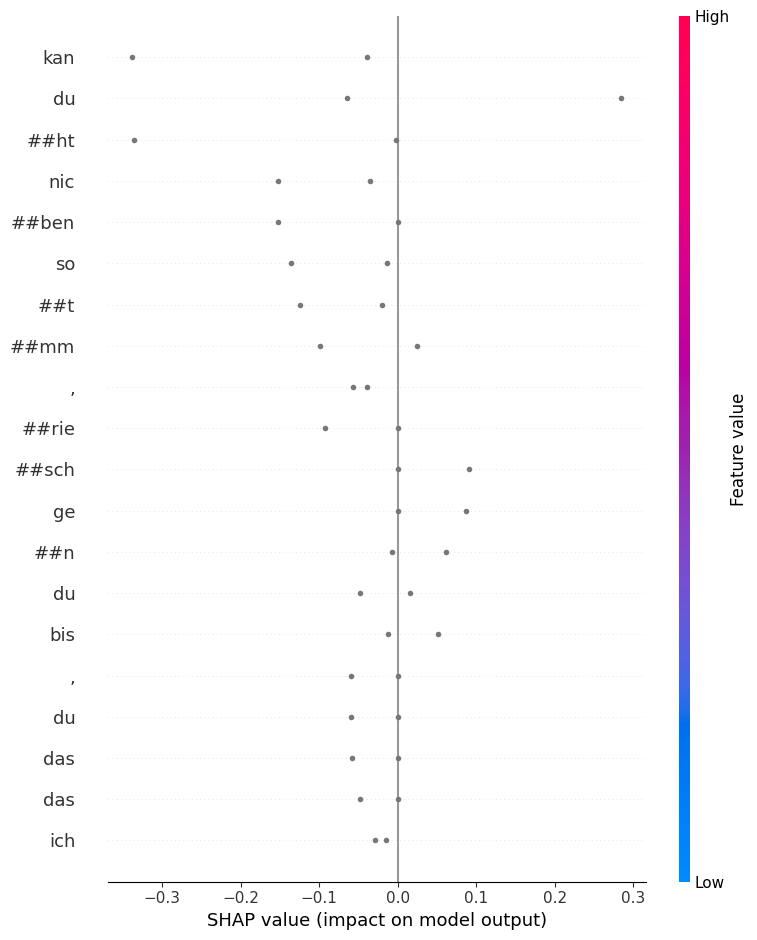


Force Plot for Sample 1: Du bist so dumm, ich kann nicht glauben, dass du das geschrieben hast!


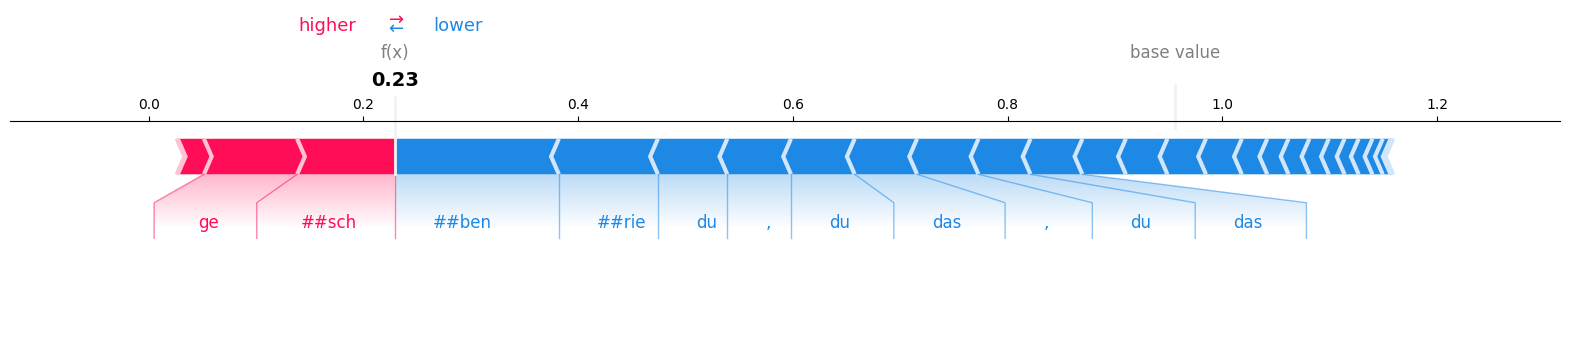


Force Plot for Sample 2: Ich wünsche dir einen schönen Tag!


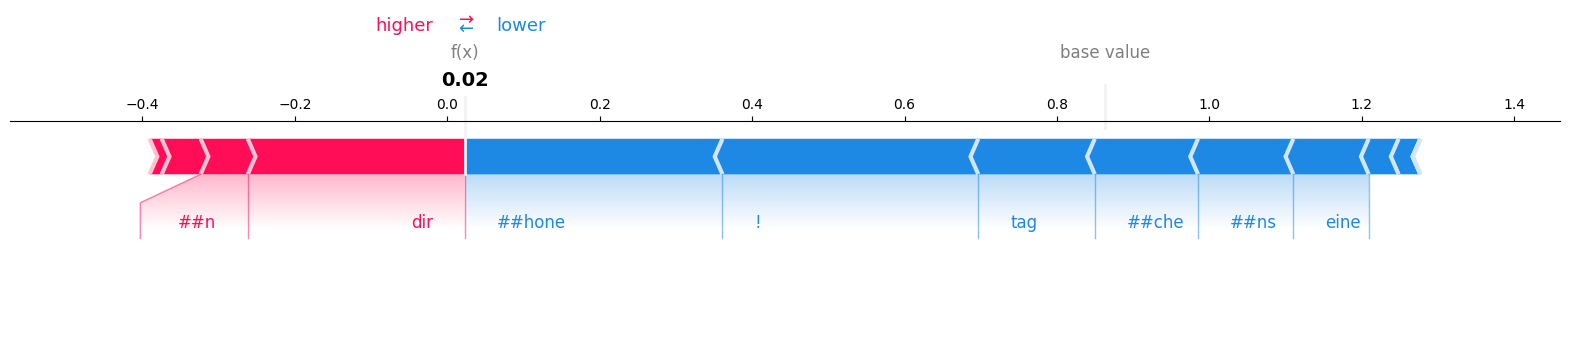

In [ ]:
# Install required libraries
!pip install shap transformers torch

# Import libraries
import shap
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the trained model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("./saved_model")
tokenizer = AutoTokenizer.from_pretrained("./saved_model")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# Define predict_proba for SHAP
def predict_proba(texts):
    # Ensure input is in the correct format
    if isinstance(texts, str):
        texts = [texts]
    elif isinstance(texts, list) and all(isinstance(t, list) for t in texts):
        texts = [" ".join(tokens) for tokens in texts]
    elif isinstance(texts, np.ndarray):
        texts = texts.tolist()
    elif not isinstance(texts, list) or not all(isinstance(t, str) for t in texts):
        raise ValueError(f"Unexpected input format: {type(texts)}")

    # Tokenize the input texts
    inputs = tokenizer(
        texts, truncation=True, max_length=128, padding=True, return_tensors="pt"
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    # Predict probabilities
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

# Initialize SHAP Explainer with Text Masker
masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker)

# SHAP Analysis on Example Texts
sample_texts = [
    "Du bist so dumm, ich kann nicht glauben, dass du das geschrieben hast!",  # Toxic
    "Ich wünsche dir einen schönen Tag!",  # Non-toxic
]

# Compute SHAP values for the sample texts
shap_values = explainer(sample_texts)

# Extract Tokens and SHAP Values
tokens_list = [
    tokenizer.convert_ids_to_tokens(tokenizer(sample, truncation=True)["input_ids"])
    for sample in sample_texts
]

# Compute SHAP values and normalize
max_len = max(len(value.values) for value in shap_values)  # Find the max length of SHAP values

# Normalize SHAP values and tokens
normalized_shap_values = [
    np.pad(value.values[:, 1], (0, max_len - len(value.values[:, 1])), constant_values=0)
    for value in shap_values
]
normalized_tokens = [
    tokens + ['[PAD]'] * (max_len - len(tokens)) for tokens in tokens_list
]

# Convert normalized SHAP values to a NumPy array
normalized_shap_values = np.array(normalized_shap_values)

# SHAP Summary Plot with Feature Names
shap.initjs()
shap.summary_plot(
    shap_values=normalized_shap_values,   # Normalized SHAP values
    features=np.array(normalized_tokens),  # Tokens as features
    feature_names=normalized_tokens[0]    # Explicitly pass tokens as feature names
)



# SHAP Force Plot
for i, text in enumerate(sample_texts):
    print(f"\nForce Plot for Sample {i + 1}: {text}")
    shap.force_plot(
        base_value=shap_values[i].base_values[1],  # Base value for the positive class
        shap_values=shap_values[i].values[:, 1],  # SHAP values for the positive class
        features=tokens_list[i],                  # Tokens for the sample
        matplotlib=True                           # Render using Matplotlib
    )



In [ ]:
# Calculate feature importance
feature_importance = np.mean(np.abs(normalized_shap_values), axis=0)

# Create a list of tokens with their importance
feature_importance_data = list(zip(normalized_tokens[0], feature_importance))

# Sort tokens by importance
sorted_feature_importance = sorted(feature_importance_data, key=lambda x: x[1], reverse=True)

# Display Top 10 Most Important Features
print("\nTop 10 Most Important Features (Tokens):")
for token, importance in sorted_feature_importance[:10]:
    print(f"Token: {token}, Importance: {importance:.4f}")

# Save Feature Importance to CSV
import csv
with open("feature_importance.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Token", "Importance"])
    writer.writerows(sorted_feature_importance)

print("\nFeature importance saved to 'feature_importance.csv'.")



Top 10 Most Important Features (Tokens):
Token: kan, Importance: 0.1885
Token: du, Importance: 0.1746
Token: ##ht, Importance: 0.1688
Token: nic, Importance: 0.0944
Token: ##ben, Importance: 0.0764
Token: so, Importance: 0.0743
Token: ##t, Importance: 0.0724
Token: ##mm, Importance: 0.0616
Token: ,, Importance: 0.0482
Token: ##rie, Importance: 0.0461

Feature importance saved to 'feature_importance.csv'.
